## Let's load the necessary libraries and assemblies

In [1]:
import os
import io
import uuid
import base64
import mimetypes

from dotenv import load_dotenv
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from openai import OpenAI
from pathlib import Path
from typing import Any, Literal, Optional
from typing_extensions import TypedDict, Annotated

## Load the .env file

In [2]:
load_dotenv()
LLM_MODEL = os.getenv("OPENAI_MODEL", "gpt-4.1-mini")   # vision-capable for images
STT_MODEL = os.getenv("STT_MODEL", "whisper-1") # speech-to-text

## Let's declare some constants

In [3]:
WAV_FILE = "./media/6_Channel_ID.wav"
JPG_FILE = "./media/_2aab1438-b09a-407a-b6a8-578c09522d7a.jpeg"
IMAGE_EXT = {".png", ".jpg", ".jpeg", ".webp", ".bmp", ".gif"}
AUDIO_EXT = {".wav", ".mp3", ".m4a", ".aac", ".flac", ".ogg", ".opus"}

## Let's instantiate the OpenAI models and objects

In [4]:
llm = ChatOpenAI(model=LLM_MODEL, temperature=0)
oai = OpenAI()

## Define utility functions

In [5]:
def _guess_modality_from_path(path: str) -> Optional[Literal["image", "audio"]]:
    ext = os.path.splitext(path.lower())[1]
    if(ext in IMAGE_EXT):
        return "image"
    if(ext in AUDIO_EXT):
        return "audio"
    return None

def _detect_modality(raw: Any, filename: Optional[str] = None) -> Literal["text", "image", "audio"]:
    """
    raw can be:
      - text: str (non-path)
      - file path: str (existing file, extension-driven)
      - bytes-like (filename strongly recommended)
      - tuple: (filename, bytes)
    """
    if(isinstance(raw, tuple) and len(raw) == 2 and isinstance(raw[0], str)):
        filename = raw[0]
        raw = raw[1]

    if(isinstance(raw, str)):
        if os.path.exists(raw):
            m = _guess_modality_from_path(raw)
            if m:
                return m
        return "text"

    if(isinstance(raw, (bytes, bytearray))):
        if(filename):
            ext = os.path.splitext(filename.lower())[1]
            if( ext in IMAGE_EXT):
                return "image"
            if( ext in AUDIO_EXT):
                return "audio"
        # Fallback when bytes have no filename: choose audio as a conservative default
        # (You can change this to "text" if your use case is different.)
        return "audio"

    return "text"

def _file_to_data_url(path: str) -> str:
    mime, _ = mimetypes.guess_type(path)
    mime = mime or "application/octet-stream"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

def _bytes_to_data_url(data: bytes, filename: str) -> str:
    mime, _ = mimetypes.guess_type(filename)
    mime = mime or "application/octet-stream"
    b64 = base64.b64encode(data).decode("utf-8")
    return f"data:{mime};base64,{b64}"

def _transcribe_audio(raw: Any, filename: Optional[str] = None) -> str:
    """
    raw can be:
      - audio file path (str)
      - bytes/bytearray (best with filename)
      - tuple (filename, bytes)
    """
    if(isinstance(raw, tuple) and len(raw) == 2 and isinstance(raw[0], str)):
        filename = raw[0]
        raw = raw[1]

    if(isinstance(raw, str) and os.path.exists(raw)):
        with open(raw, "rb") as f:
            tr = oai.audio.transcriptions.create(model=STT_MODEL, file=f)
        return getattr(tr, "text", str(tr))

    if(isinstance(raw, (bytes, bytearray))):
        bio = io.BytesIO(bytes(raw))
        bio.name = filename or "audio.wav"  # OpenAI client uses .name as a filename hint
        tr = oai.audio.transcriptions.create(model=STT_MODEL, file=bio)
        return getattr(tr, "text", str(tr))

    raise ValueError("Unsupported audio input for transcription.")

## Let's define the AgentState

In [6]:
class AgentState(TypedDict, total=False):
    messages: Annotated[list, add_messages]

    raw: Any
    filename: Optional[str]

    modality: Literal["text", "image", "audio"]

    transcript: str
    user_input: str
    request_id: str

## Let's define the nodes, those that we pass the AgentState object(s) into

In [7]:
def router_node(state: AgentState) -> dict:
    raw = state.get("raw")
    filename = state.get("filename")
    modality = _detect_modality(raw, filename=filename)
    state["modality"] = modality
    state["request_id"] = state.get("request_id") or str(uuid.uuid4())
    return state

def route_after_router(state: AgentState) -> Literal["prep_text", "prep_image", "prep_audio"]:
    m = state["modality"]
    if(m == "image"):
        return "prep_image"
    if(m == "audio"):
        return "prep_audio"
    return "prep_text"

def prep_text(state: AgentState) -> dict:
    raw = state["raw"]
    if(isinstance(raw, tuple)):  # (filename, bytes)
        raw = raw[1]
        
    text = raw.decode("utf-8", errors="replace") if isinstance(raw, (bytes, bytearray)) else str(raw)
    
    state["user_input"] = text
    state["messages"] = state["messages"] + [HumanMessage(content=text)]
    
    return state

def prep_image(state: AgentState) -> dict:
    raw = state["raw"]
    filename = state.get("filename")

    if(isinstance(raw, str) and os.path.exists(raw)):
        data_url = _file_to_data_url(raw)
        shown_name = os.path.basename(raw)
    elif(isinstance(raw, tuple) and len(raw) == 2):
        shown_name = raw[0]
        data_url = _bytes_to_data_url(raw[1], shown_name)
    elif(isinstance(raw, (bytes, bytearray))):
        shown_name = filename or "image.png"
        data_url = _bytes_to_data_url(bytes(raw), shown_name)
    else:
        raise ValueError("Unsupported image input.")

    msg = HumanMessage(content=[
        {"type": "text", "text": "Deeply analyze the image. Describe what you see and answer any implied user intent. Limit your words to not exceed 500 words."},
        {"type": "image_url", "image_url": {"url": data_url}},
    ])

    state["user_input"] = f"[image:{shown_name}]"                                             
    state["messages"] = state["messages"] + [msg]
                                             
    return state

def prep_audio(state: AgentState) -> dict:
    raw = state["raw"]
    filename = state.get("filename")

    transcript = _transcribe_audio(raw, filename=filename)
    msg = HumanMessage(content=f"(audio transcript)\n{transcript}")
    
    state["transcript"] = transcript
    state["user_input"] = f"[audio:{filename or 'audio'}] {transcript[:200]}"
    state["messages"] = state["messages"] + [msg]
    
    return state

def agent_node(state: AgentState) -> dict:
    # Single-shot assistant; you can expand into tool loops later if needed
    resp = llm.invoke(state["messages"])
    state["messages"] = state["messages"] + [resp]
    return state

## Let's build the node and the edges

In [8]:
checkpointer = InMemorySaver()
builder = StateGraph(AgentState)
builder.add_node("router", router_node)
builder.add_node("prep_text", prep_text)
builder.add_node("prep_image", prep_image)
builder.add_node("prep_audio", prep_audio)
builder.add_node("agent", agent_node)

builder.add_edge(START, "router")
builder.add_conditional_edges(
    "router", route_after_router, {
    "prep_text": "prep_text",
    "prep_image": "prep_image",
    "prep_audio": "prep_audio",
})

builder.add_edge("prep_text", "agent")
builder.add_edge("prep_image", "agent")
builder.add_edge("prep_audio", "agent")
builder.add_edge("agent", END)

graph = builder.compile(checkpointer=checkpointer)

## Let's visualize our (LANG)graph

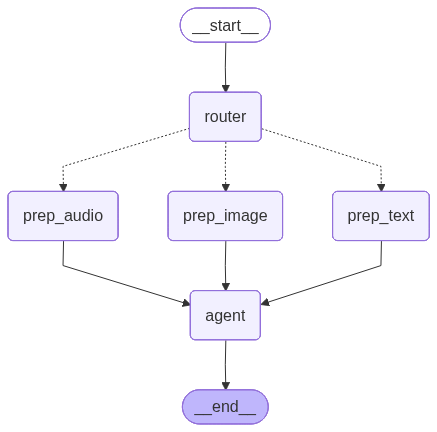

In [9]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Let's define our initial payload and chat with our agent

In [39]:
def run_agent(raw: Any, filename: Optional[str] = None,thread_id="demo",display_tool_call=True) -> str:
    cfg = {"configurable": {"thread_id": thread_id}}
    final_state = graph.invoke({"raw": raw,"filename":filename}, config=cfg)
    
    if(display_tool_call):
        print("yay")
        for msg in final_state["messages"]:
            if(hasattr(msg,"tool_calls")):
                for index, tool_call in enumerate(msg.tool_calls):
                    print("*"*100)
                    print(f"Tool Call: #{index+1}| Name: {tool_call["name"]}| Args: {tool_call["args"]}")    
    
    # The latest assistant message is at the end
    return final_state["messages"][-1].content

print(run_agent("Summarize the key risk factors for dehydration."))

yay
Key risk factors for dehydration include:

- Insufficient fluid intake  
- Excessive fluid loss (through sweating, vomiting, diarrhea)  
- Age extremes (infants and elderly)  
- Medical conditions like fever, diabetes, or kidney disease  
- Use of diuretics or laxatives  
- Hot or humid weather  
- Intense physical activity without adequate hydration  
- Alcohol consumption  

These factors increase the likelihood of the body losing more fluids than it replaces.


## based on the filepath

In [40]:
print(run_agent(JPG_FILE))  # routes based on extension

yay
The image captures a joyful and proud moment of two young graduates, a male and a female, smiling warmly at the camera. Both are dressed in traditional academic regalia, including black mortarboards with tassels and black gowns, symbolizing their successful completion of an academic program. Their attire is enhanced with colorful stoles and medals, indicating academic honors or distinctions. The male graduate wears an orange stole with blue ribbons and medals, while the female graduate sports a pink and blue stole, complemented by a floral corsage pinned to her gown, adding a festive and personal touch.

Their expressions convey happiness, pride, and accomplishment, reflecting the significance of this milestone. The background shows other graduates seated in rows, also in academic regalia, suggesting a formal outdoor graduation ceremony on a university or college campus. The setting includes tall buildings and lush greenery, contributing to the atmosphere of an important academic e

## Greetings and salutations

In [41]:
run_agent("Hi")

yay


'Hello! How can I assist you today?'

In [42]:
run_agent("Hi, im brando, what's your name?")

yay


'Hi Brando! I’m ChatGPT, your AI assistant. How can I help you today?'

In [43]:
run_agent("what's my name?")

yay


'You mentioned that your name is Brando. How can I assist you further?'

## WAV BYTES upload example

In [44]:
wav_file = Path(WAV_FILE).resolve()

if(not wav_file.exists()):
    raise FileNotFoundError(
        f"File not found at {WAV_FILE}"
    )
wav_bytes = open(wav_file, "rb").read()
print(run_agent((wav_file.name, wav_bytes)))    

yay
The audio transcript you provided lists common speaker positions in a surround sound system: front left, front right, center, back left, and back right. This setup is typical for a 5.0 or 5.1 surround sound configuration, designed to create an immersive audio experience by placing speakers around the listener.

If you need help with setting up a surround sound system, understanding speaker placement, or anything related to audio, feel free to ask!


## JPG  BYTES upload example

In [45]:
jpg_file = Path(JPG_FILE).resolve()

if(not jpg_file.exists()):
    raise FileNotFoundError(
        f"File not found at {JPG_FILE}."
    )
jpg_bytes = open(jpg_file, "rb").read()
print(run_agent((jpg_file.name, jpg_bytes)))    

yay
The image captures a heartfelt and celebratory moment featuring two young graduates, a male and a female, smiling warmly at the camera. Both are dressed in traditional academic regalia, including black mortarboards with tassels and black gowns, symbolizing their successful completion of an academic program. Their attire is further enhanced with colorful stoles and medals, indicating academic honors or distinctions. The male graduate wears an orange stole adorned with blue ribbons and medals, while the female graduate sports a pink and blue stole, complemented by a floral corsage pinned to her gown, adding a festive and personal touch.

Their expressions radiate pride, happiness, and accomplishment, reflecting the importance of this milestone. The background reveals other graduates seated in rows, also in academic regalia, suggesting a formal outdoor graduation ceremony held on a university or college campus. The setting includes tall buildings and lush greenery, contributing to the

## Summarize everything so far

In [46]:
print(run_agent("Summarize the activities that we have so far, the questions i asked, the media and objects i uploaded?"))

yay
Here’s a summary of our interaction so far:

**Questions Asked:**
- You asked multiple times for a summary of the key risk factors for dehydration.
- You introduced yourself as Brando and asked for my name.
- You asked me to recall your name.
- You provided an audio transcript listing speaker positions: "front left, front right, center, back left, back right."
- You requested a deep analysis and description of a graduation image multiple times.
- You asked for a summary of all activities, questions, and media shared so far.

**Media and Objects Uploaded:**
- You uploaded an image of two young graduates (a male and a female) in graduation caps and gowns, smiling at the camera during a graduation ceremony.

**Activities:**
- I provided summaries of dehydration risk factors.
- I introduced myself and acknowledged your name.
- I explained the audio transcript as speaker positions in a surround sound system.
- I deeply analyzed the graduation image multiple times, describing the scene, 

## Ask again from another thread

In [47]:
run_agent("what's my name?", thread_id="bogus-thread")

yay


"I don't have access to your name. If you'd like, you can tell me your name!"